#### Case opti-4: Isobaric evaporation of methane in a large tank for long-term storage, kawasaki example case from industry
https://global.kawasaki.com/en/corp/newsroom/news/detail/?f=20250807_3407

In [3]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import time
import time

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [4]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K


V_tank = 50000 # Tank volume / m^3

d_i = 45 # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.038 # W/m2/K
U_V = 0.038 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.9

# Specify tank operating pressure
P = 100000 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)


# # Initialise cryogen
cryogen = Cryogen(name = "methane")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Set fixed bottom heat ingress
q_b_fixed = 6.5845*U_L*(T_air - cryogen.T_sat)

large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# comparison of heat flux
print("height: ", large_tank.l, " diameter: ", large_tank.d_i)
print("the initial aspect ratio is %.3f" % (large_tank.l/large_tank.d_i))
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))
print("Q_l: ", large_tank.Q_L_in, " Q_v: ", large_tank.Q_wi)
print("Thermal aspect ratio: ", 1-large_tank.Q_b/(large_tank.Q_wi+large_tank.Q_L_in+ large_tank.Q_b))

height:  31.438013450250935  diameter:  45
the initial aspect ratio is 0.699
q_b used:  46.69997504478057  q_b free:  7.092410212587223
Q_b used:  74273.10112752659  Q_b free:  11279.991058930304
Q_l:  28937.033667355874  Q_v:  2893.7033667355868
Thermal aspect ratio:  0.2999960942563329


Calculate initial evaporation rate and transient period

In [5]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of methane is 747.3 kg/h
Transient period = 86449.113 s 
Simulation time: 25 h
BOR = 0.094 %


#### Simulation setup and execution

In [6]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6


In [7]:
opti = Opti_jax(large_tank)

+-------------------------------------------------------------+
| Optimal Thermal aspect ratio:    0.6666848617101602               |
| Optimal Geometric aspect ratio:  3.3232932932932937               |
| Minimal BOR:                     0.0007001380727778783               |
+-------------------------------------------------------------+


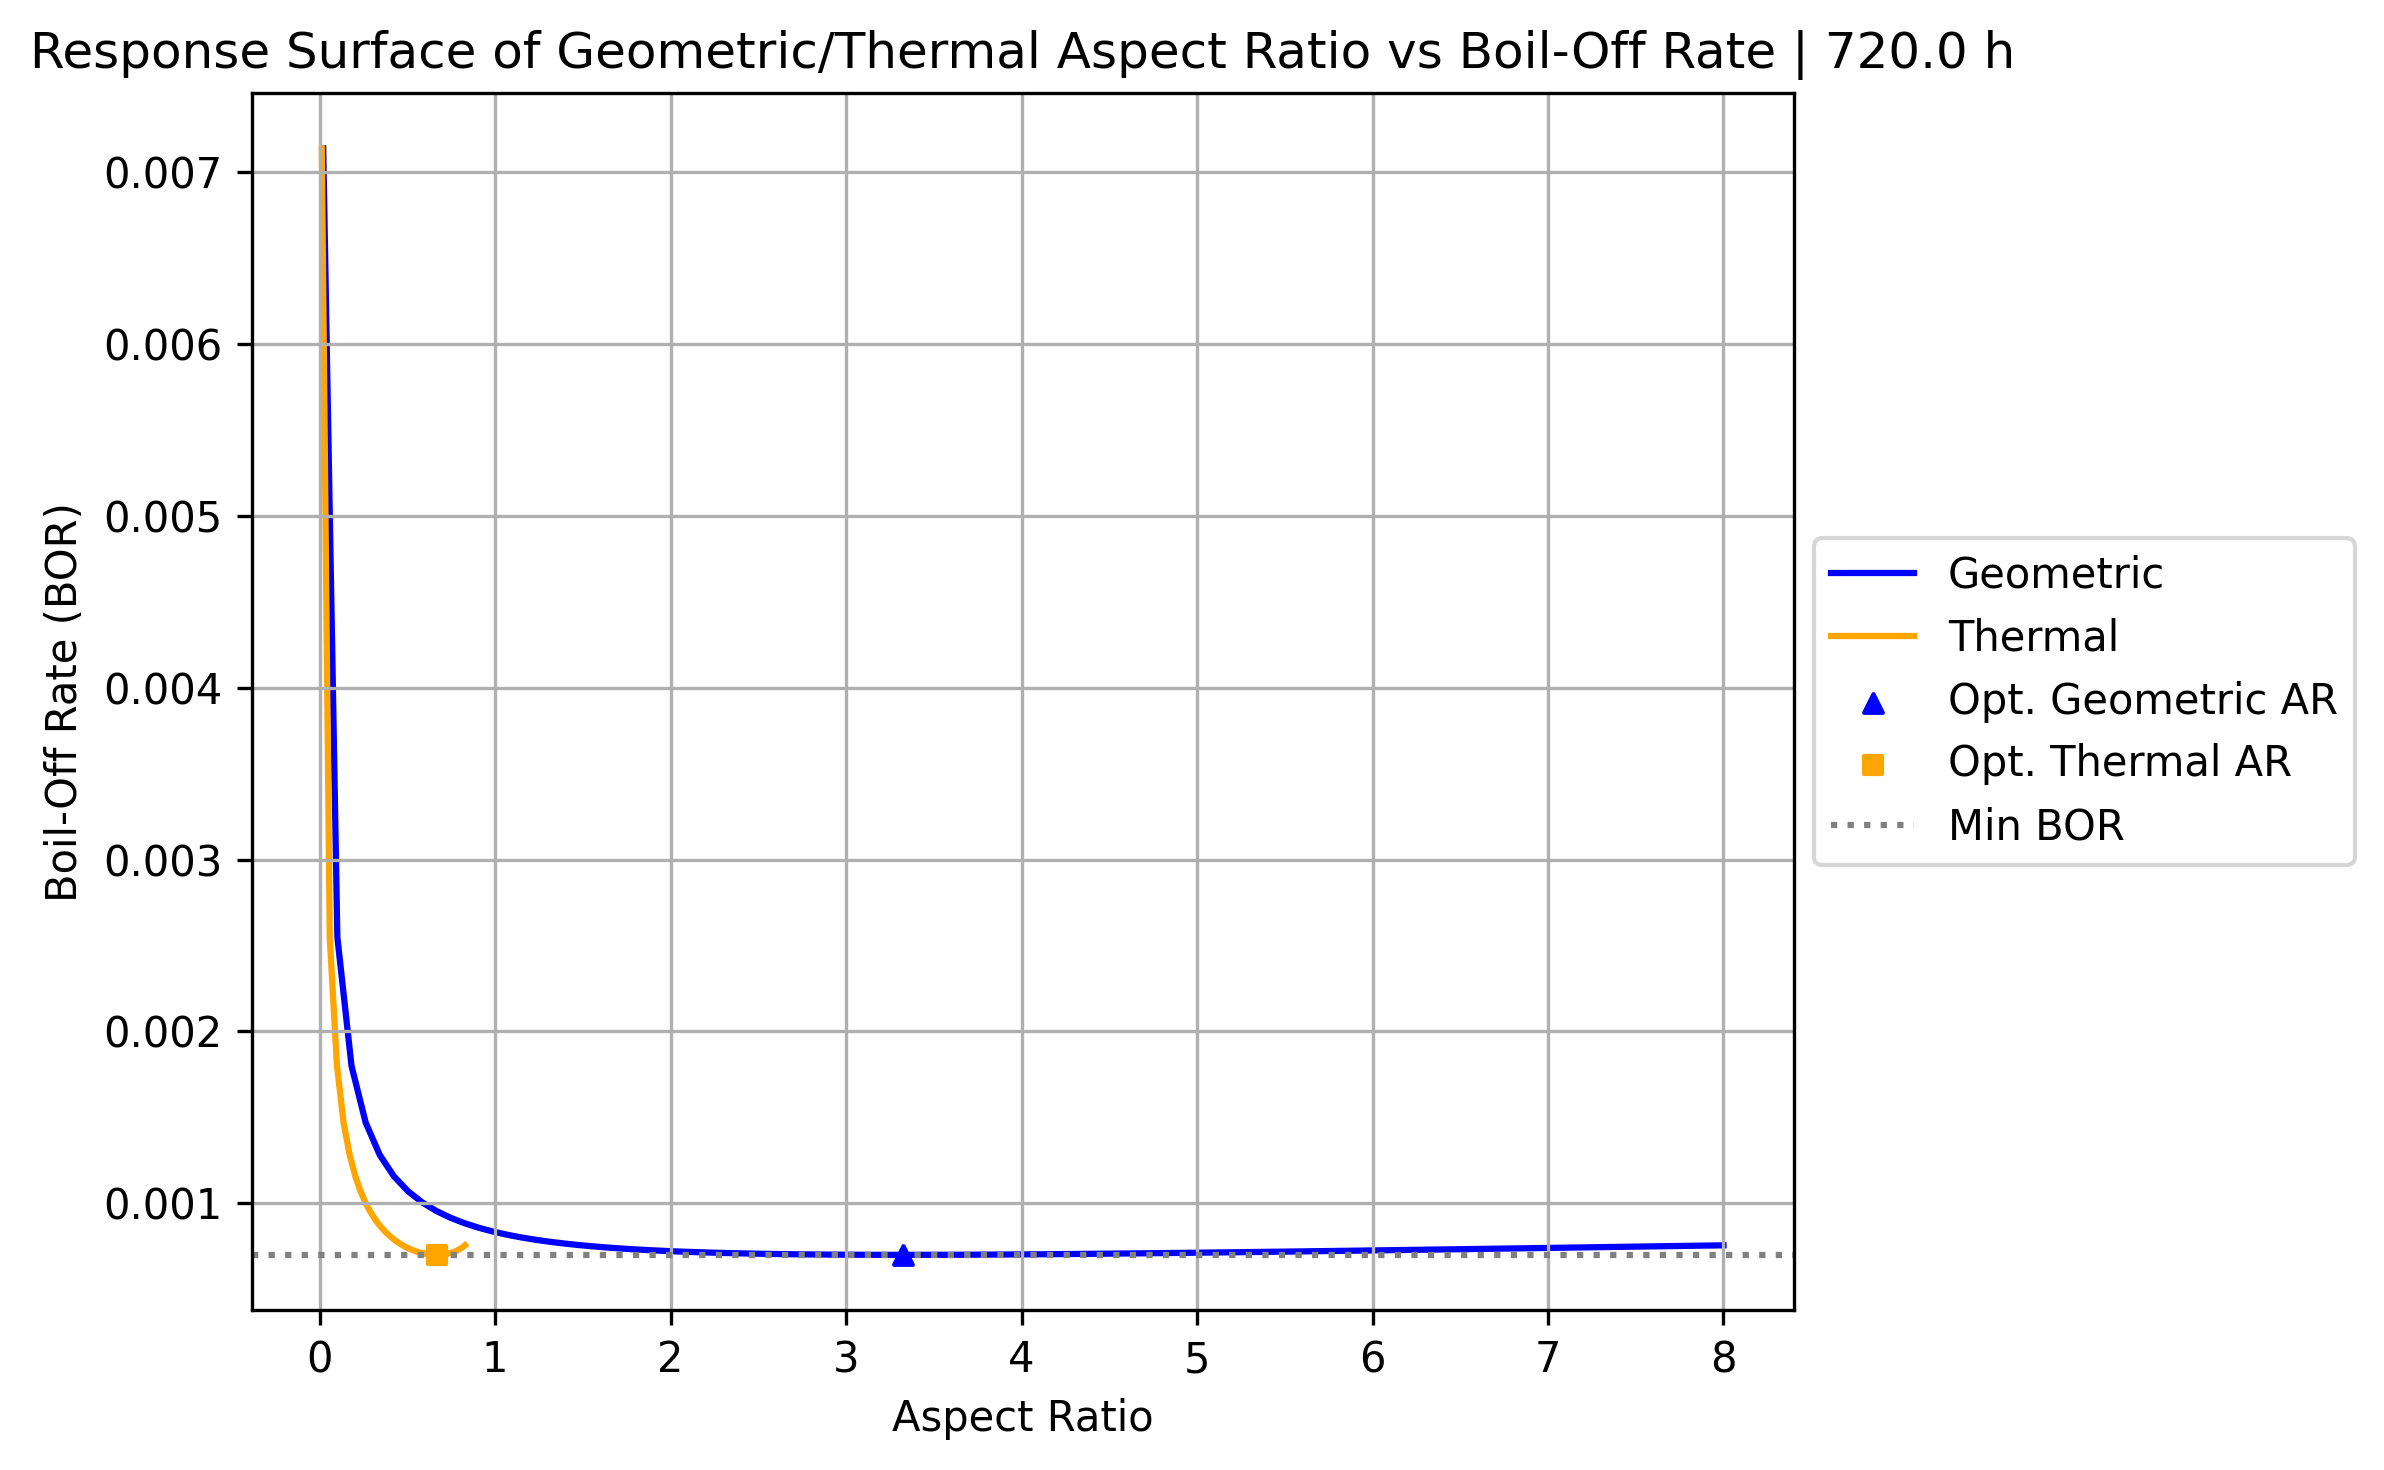

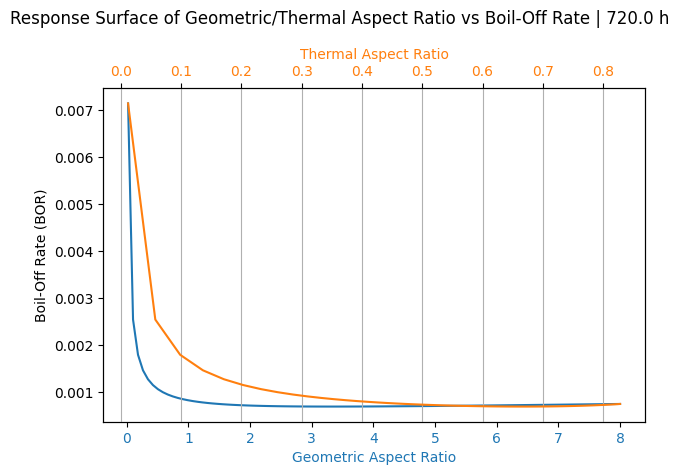

In [9]:
opti.plot_aspect_ratio_surface_response(jnp.linspace(0.02, 8, 100), 720*3600)
opti.plot_xx_aspect_ratio_surface_response(jnp.linspace(0.02, 8, 100), 720*3600)

optimal Aspect Ratio: [3.93975339 3.53081536 3.30467467]
optimal Thermal Aspect Ratio: [0.68431307 0.67096965 0.66655556]
optimal BOR: [0.01156224 0.00121821 0.00066565]


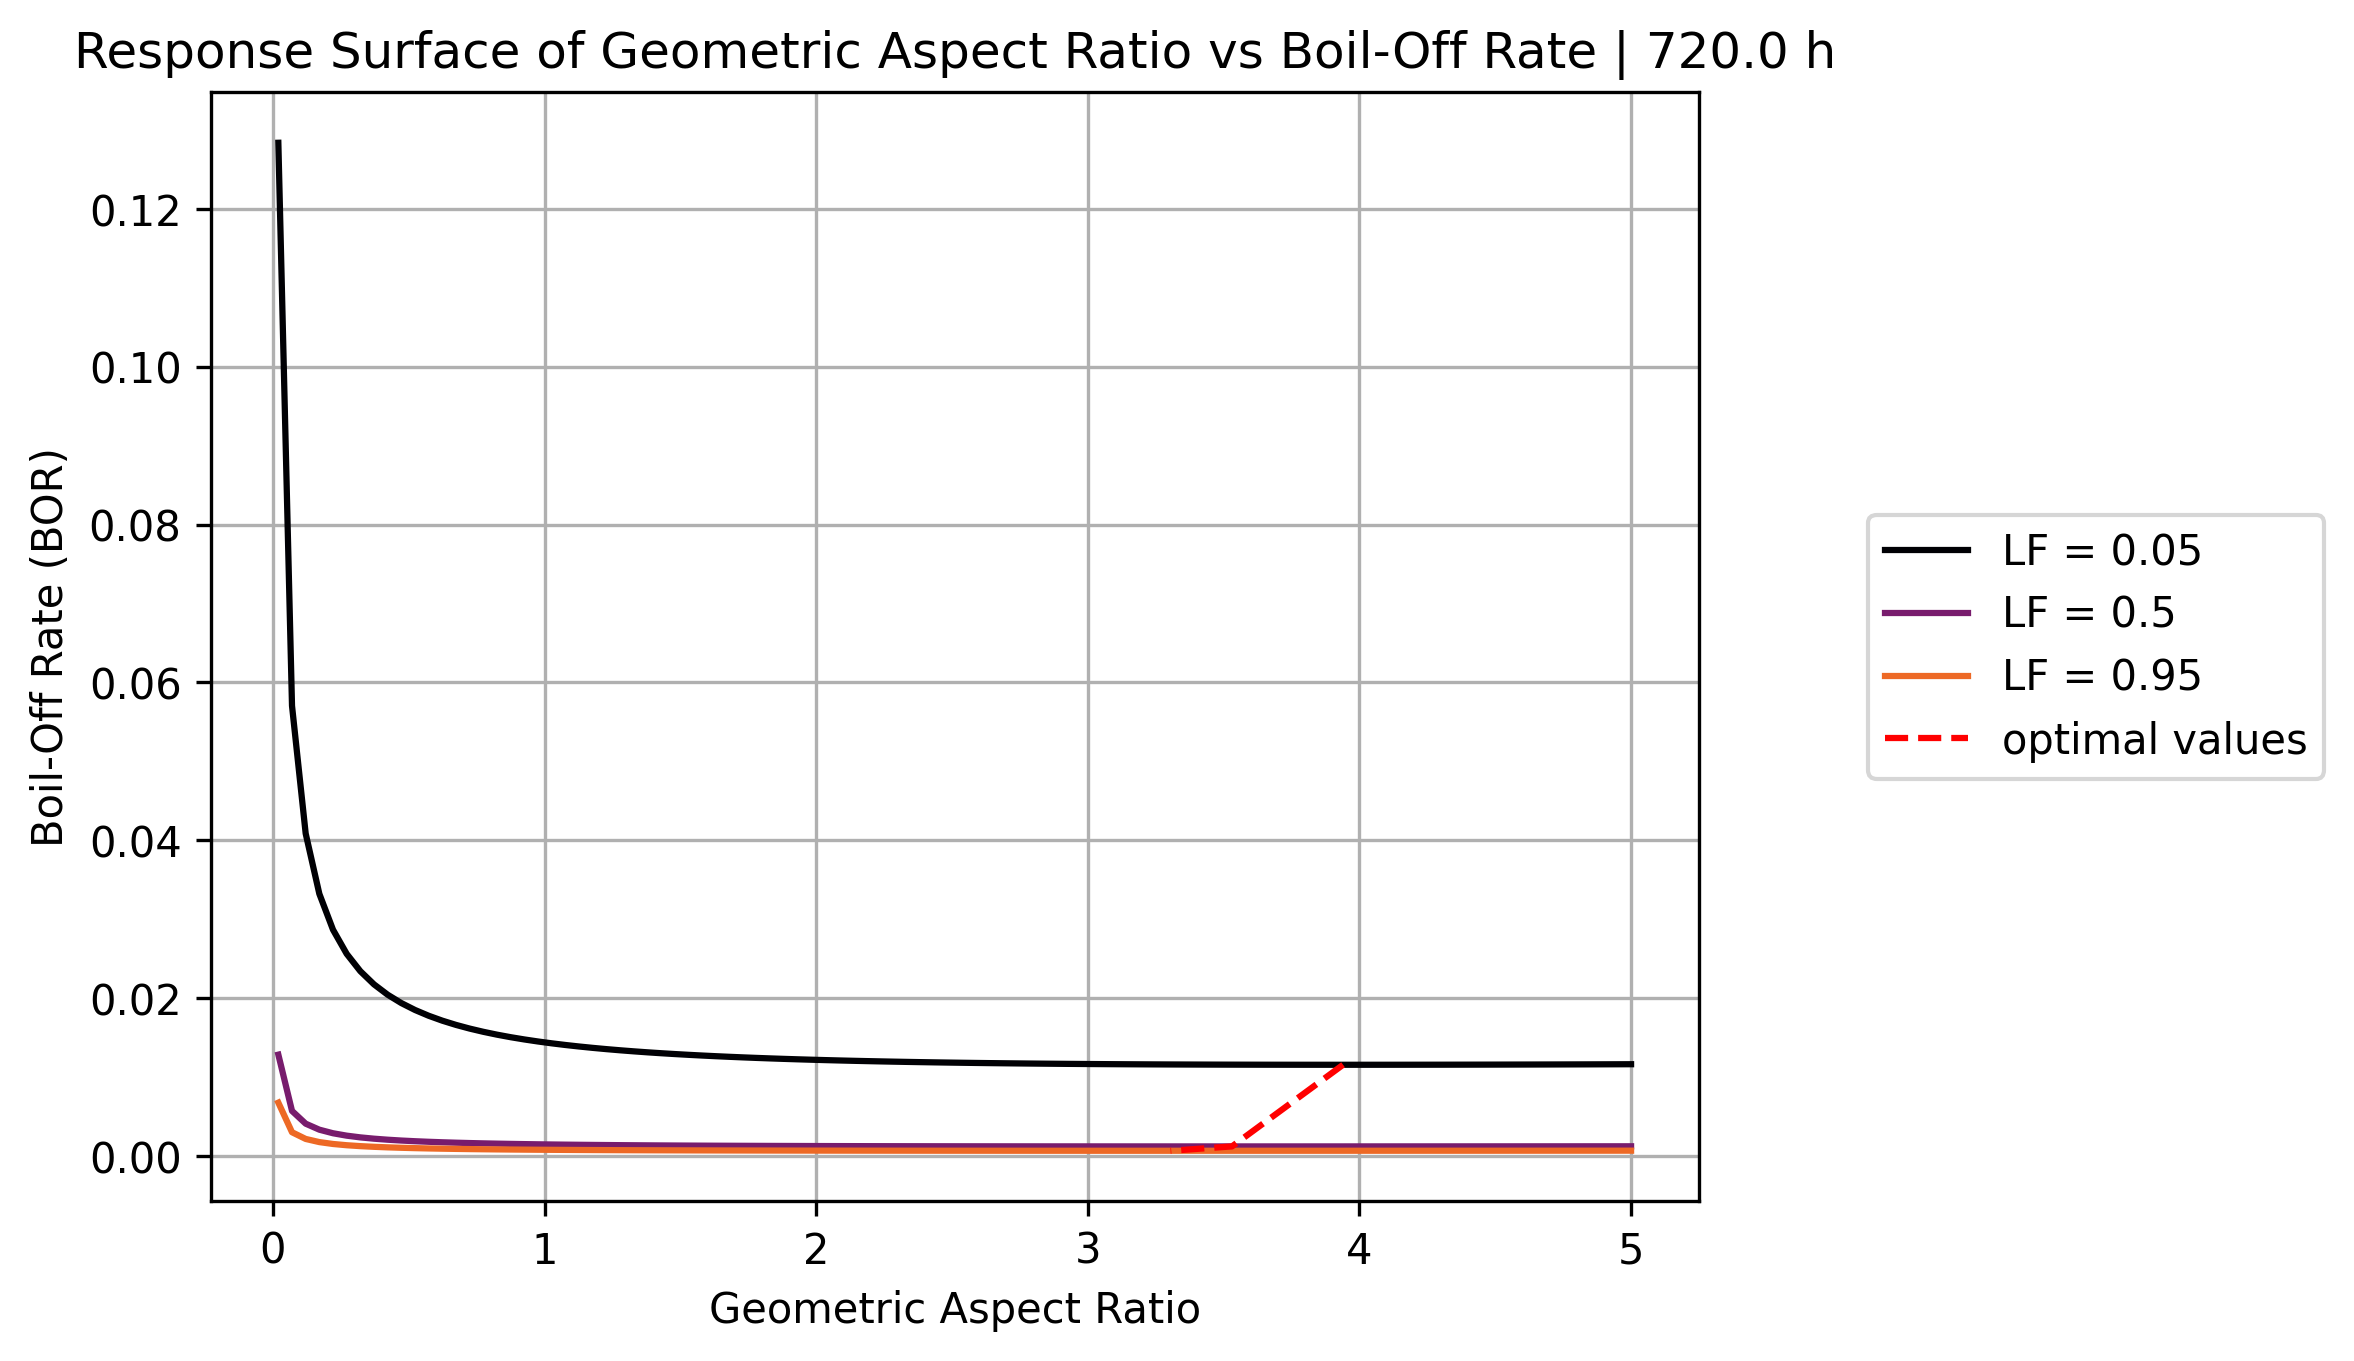

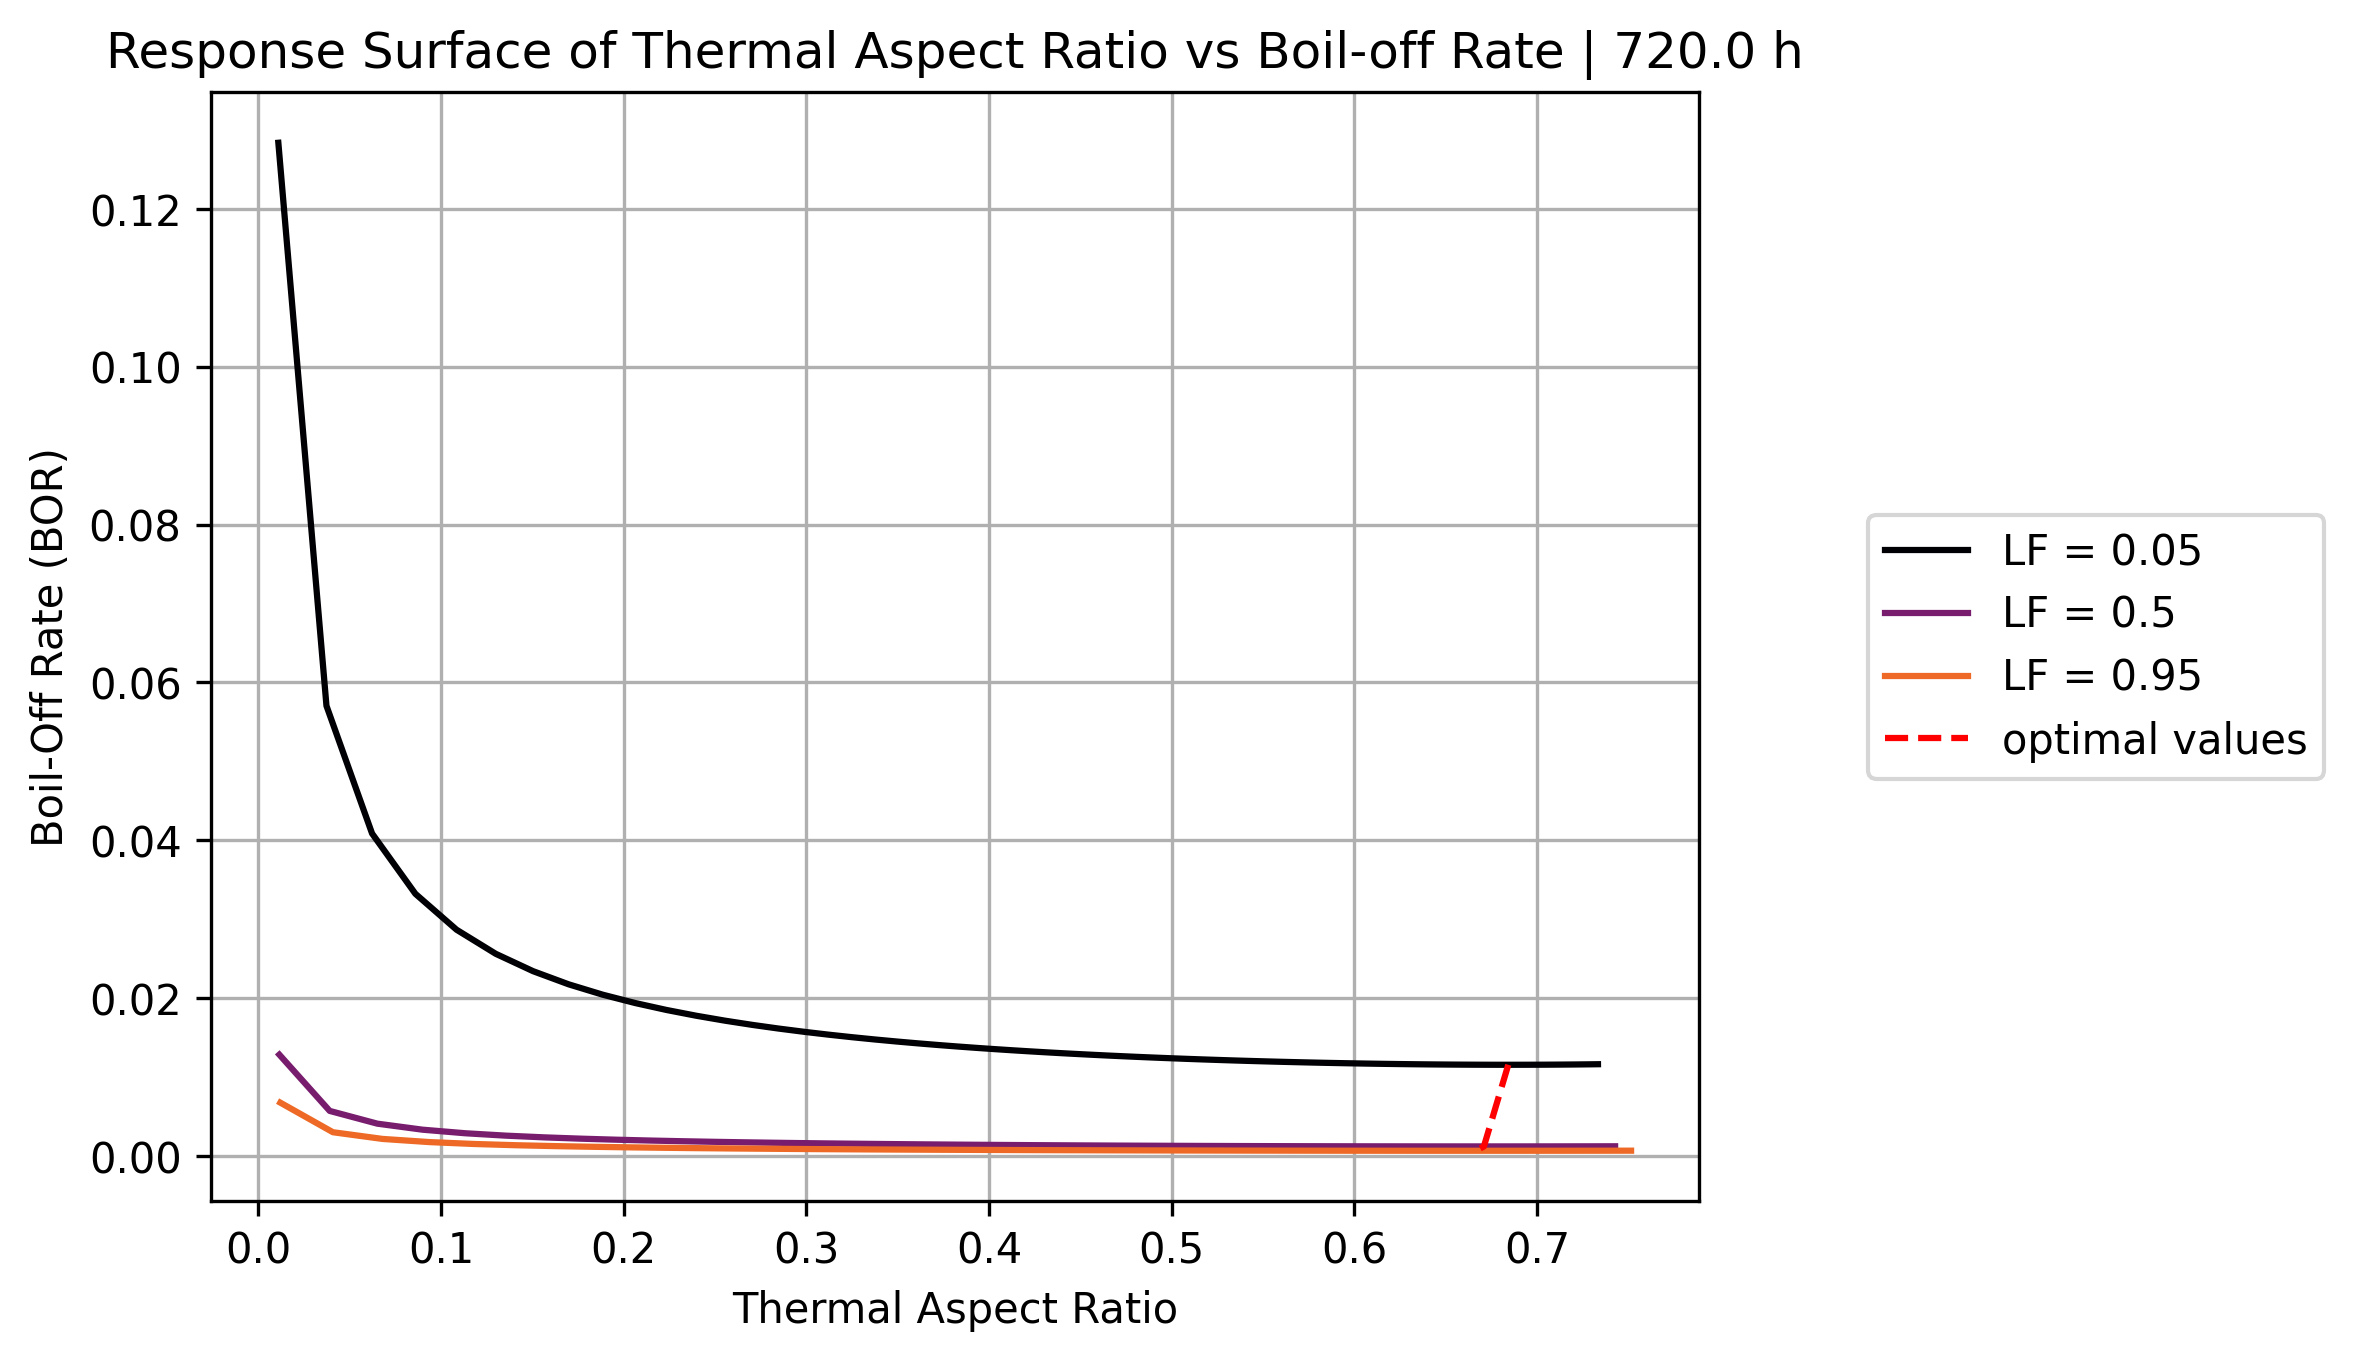

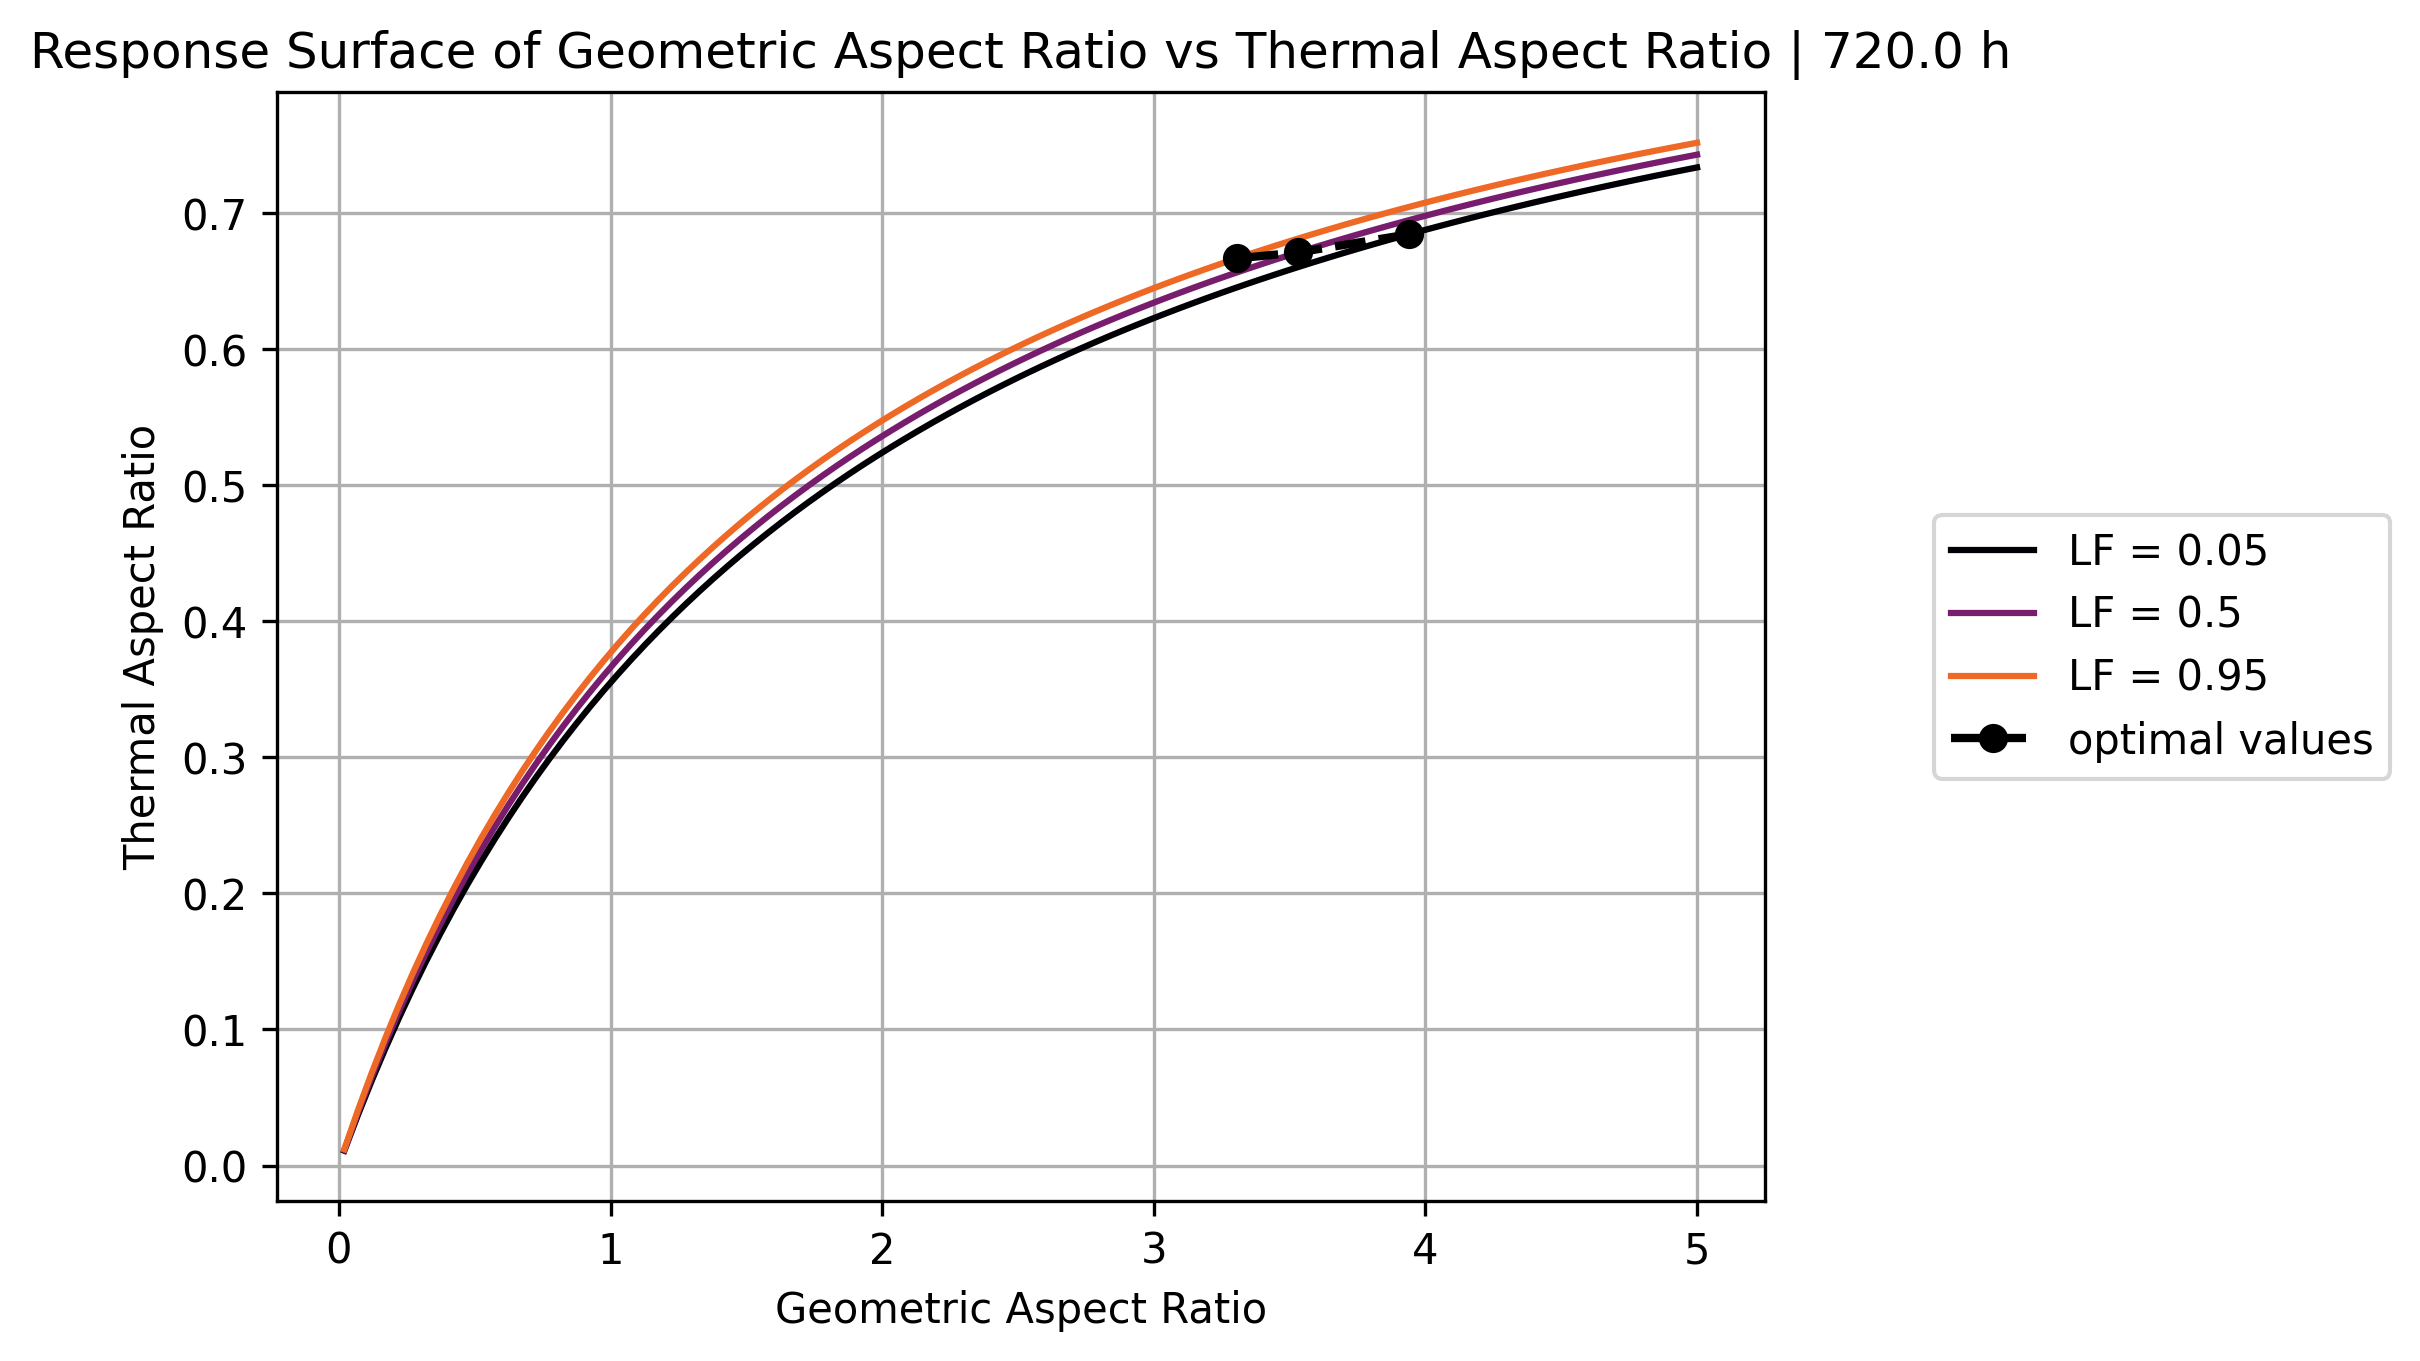

In [10]:
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.02, 5, 100), jnp.array([0.05,0.50,0.95]),720*3600)

#### Setup tank and cryogen properties r = 0.7


In [18]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K


V_tank = 50000 # Tank volume / m^3

d_i = 45 # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.038 # W/m2/K
U_V = 0.038 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.9

# Specify tank operating pressure
P = 100000 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)


# # Initialise cryogen
cryogen = Cryogen(name = "methane")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Set fixed bottom heat ingress
q_b_fixed = 1.205*U_L*(T_air - cryogen.T_sat)

large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# comparison of heat flux
print("height: ", large_tank.l, " diameter: ", large_tank.d_i)
print("the initial aspect ratio is %.3f" % (large_tank.l/large_tank.d_i))
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))
print("Q_l: ", large_tank.Q_L_in, " Q_v: ", large_tank.Q_wi)
print("Thermal aspect ratio: ", 1-large_tank.Q_b/(large_tank.Q_wi+large_tank.Q_L_in+ large_tank.Q_b))

height:  31.438013450250935  diameter:  45
the initial aspect ratio is 0.699
q_b used:  8.546354306167604  q_b free:  7.092410212587223
Q_b used:  13592.389226011017  Q_b free:  11279.991058930304
Q_l:  28937.033667355874  Q_v:  2893.7033667355868
Thermal aspect ratio:  0.7007605960853927


Calculate initial evaporation rate and transient period

In [19]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of methane is 319.9 kg/h
Transient period = 201936.403 s 
Simulation time: 57 h
BOR = 0.040 %


#### Simulation setup and execution

In [20]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6


In [21]:
opti = Opti_jax(large_tank)

+-------------------------------------------------------------+
| Optimal Thermal aspect ratio:    0.666978800803273               |
| Optimal Geometric aspect ratio:  0.6091828191828191               |
| Minimal BOR:                     0.00039750777910120273               |
+-------------------------------------------------------------+


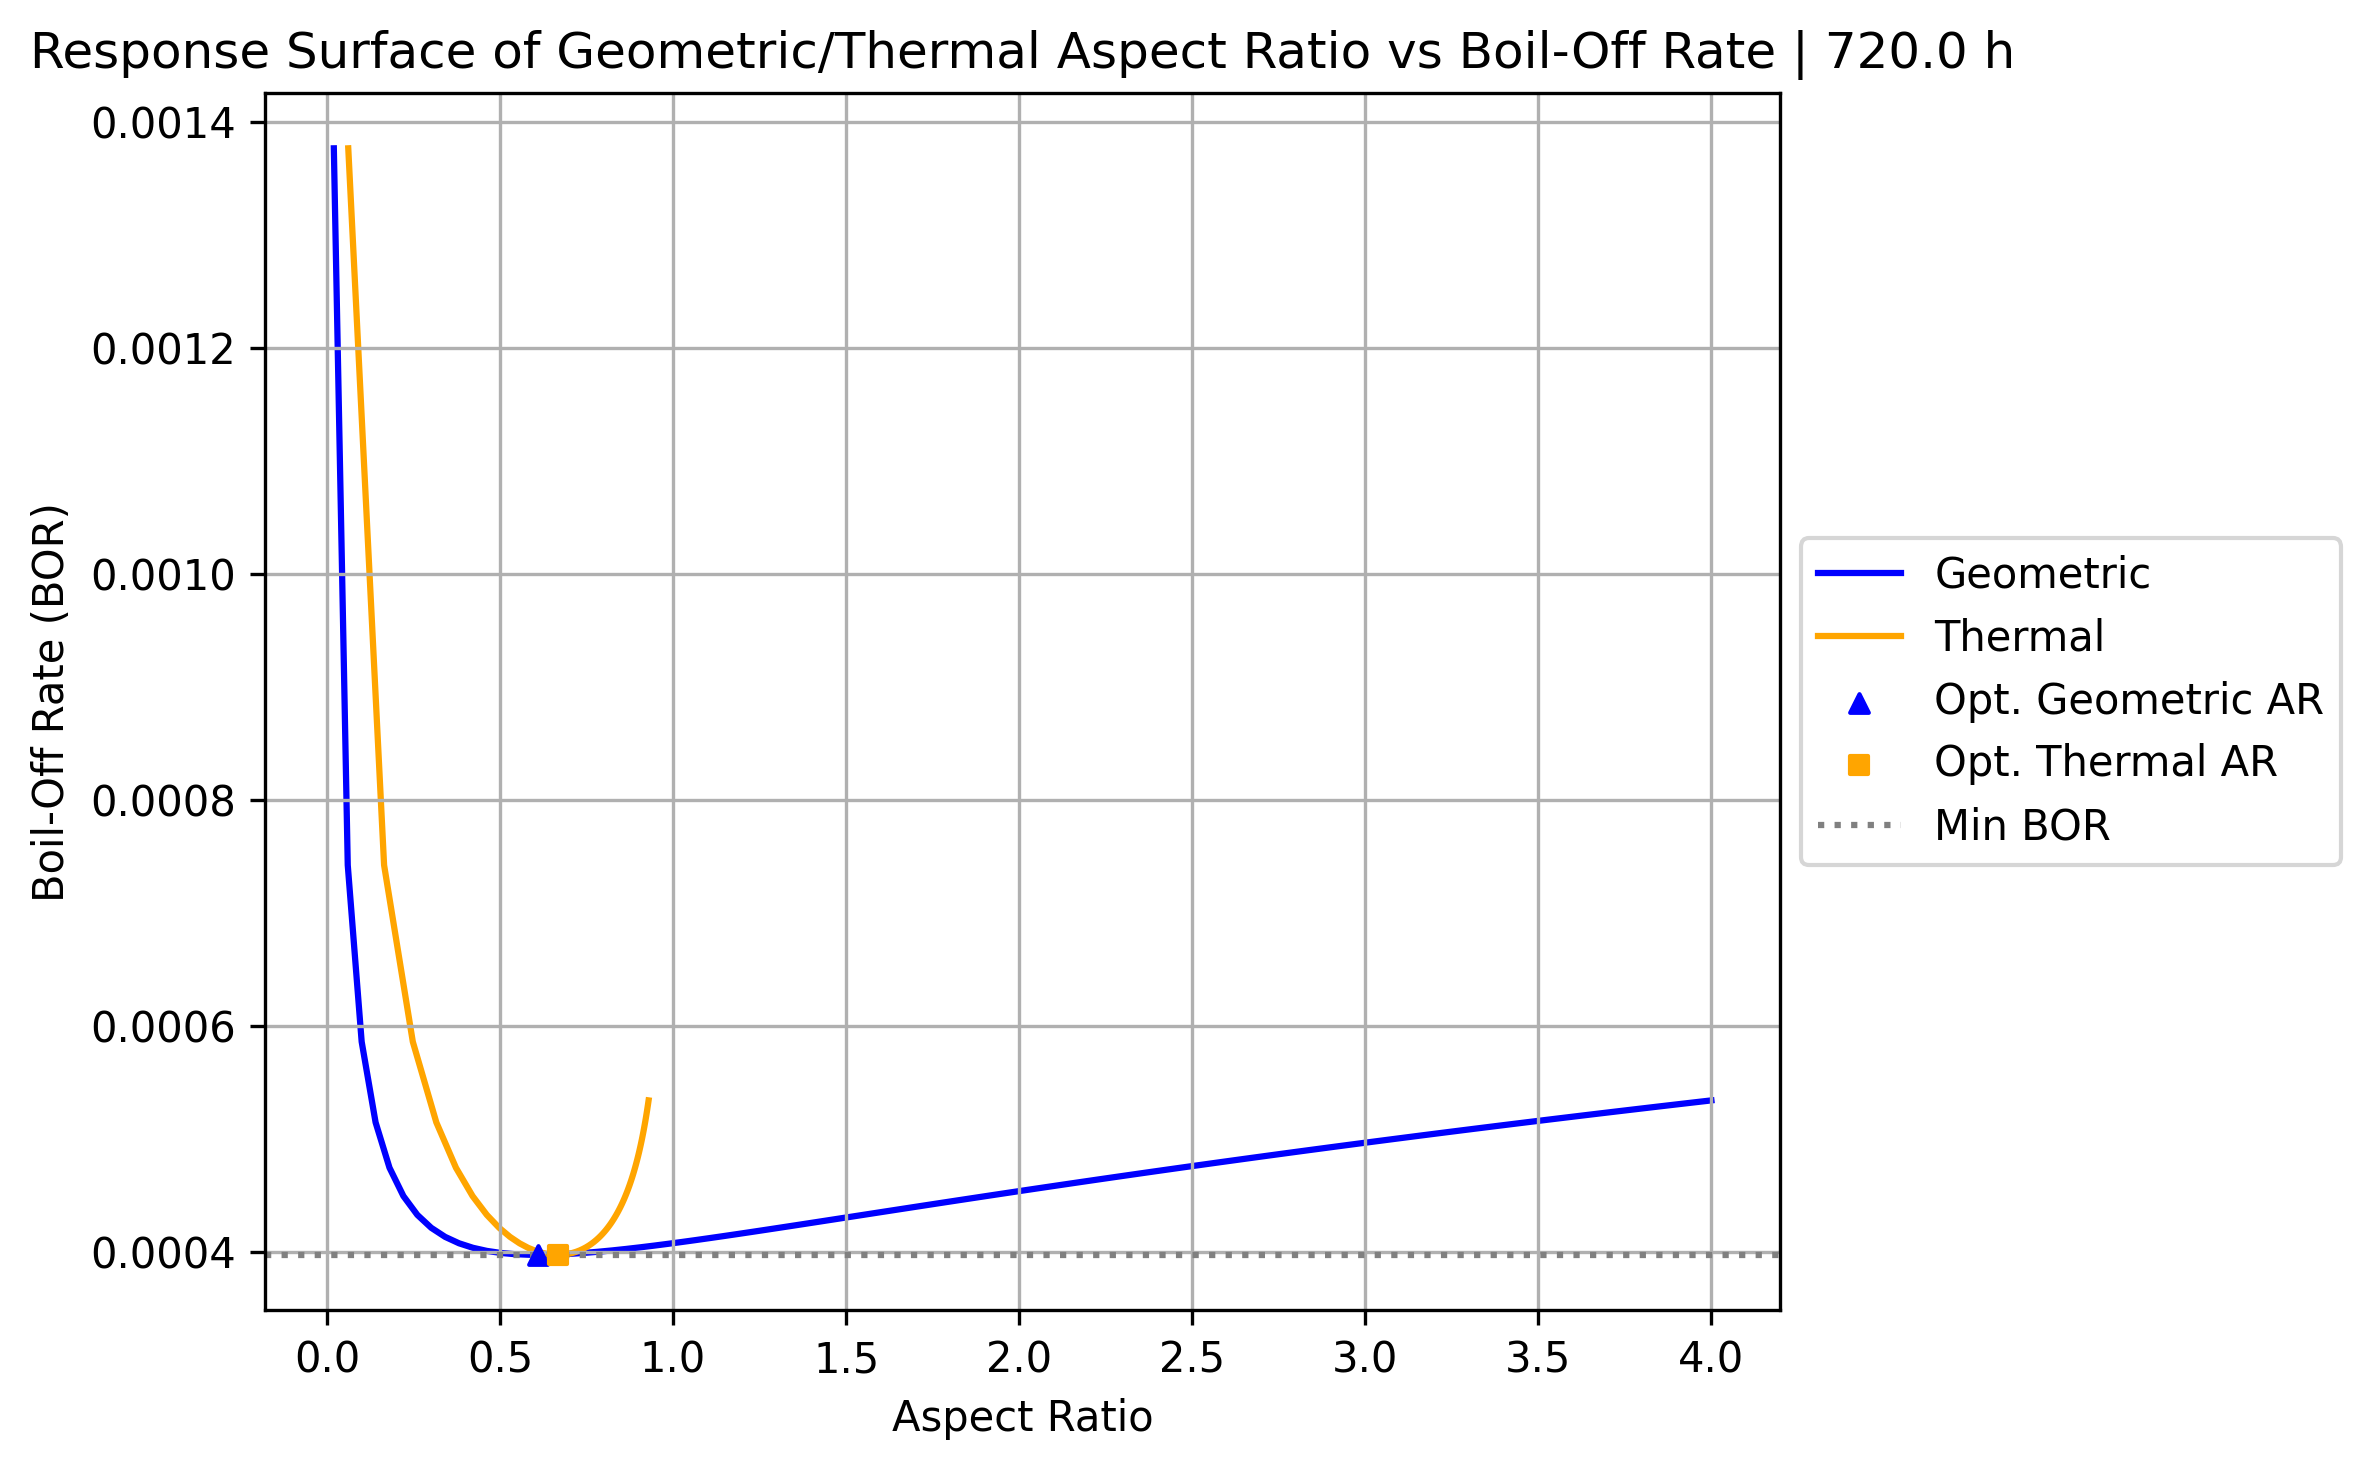

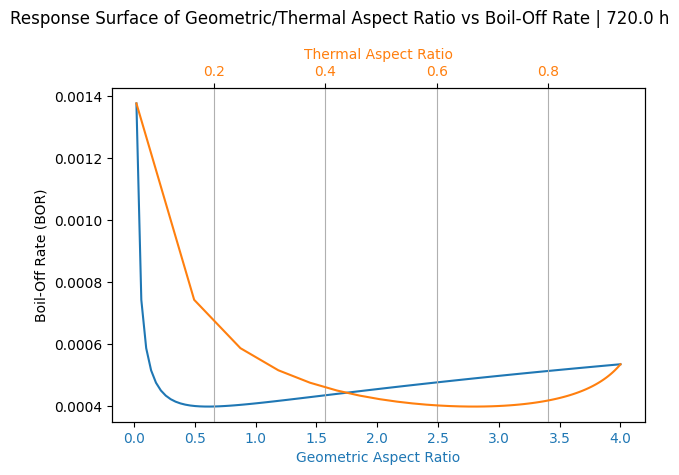

In [22]:
opti.plot_aspect_ratio_surface_response(jnp.linspace(0.02, 4, 100), 720*3600)
opti.plot_xx_aspect_ratio_surface_response(jnp.linspace(0.02, 4, 100), 720*3600)

optimal Aspect Ratio: [0.71839931 0.64692056 0.60577942]
optimal Thermal Aspect Ratio: [0.68345886 0.67115704 0.66685318]
optimal BOR: [0.00657677 0.00069181 0.00037792]


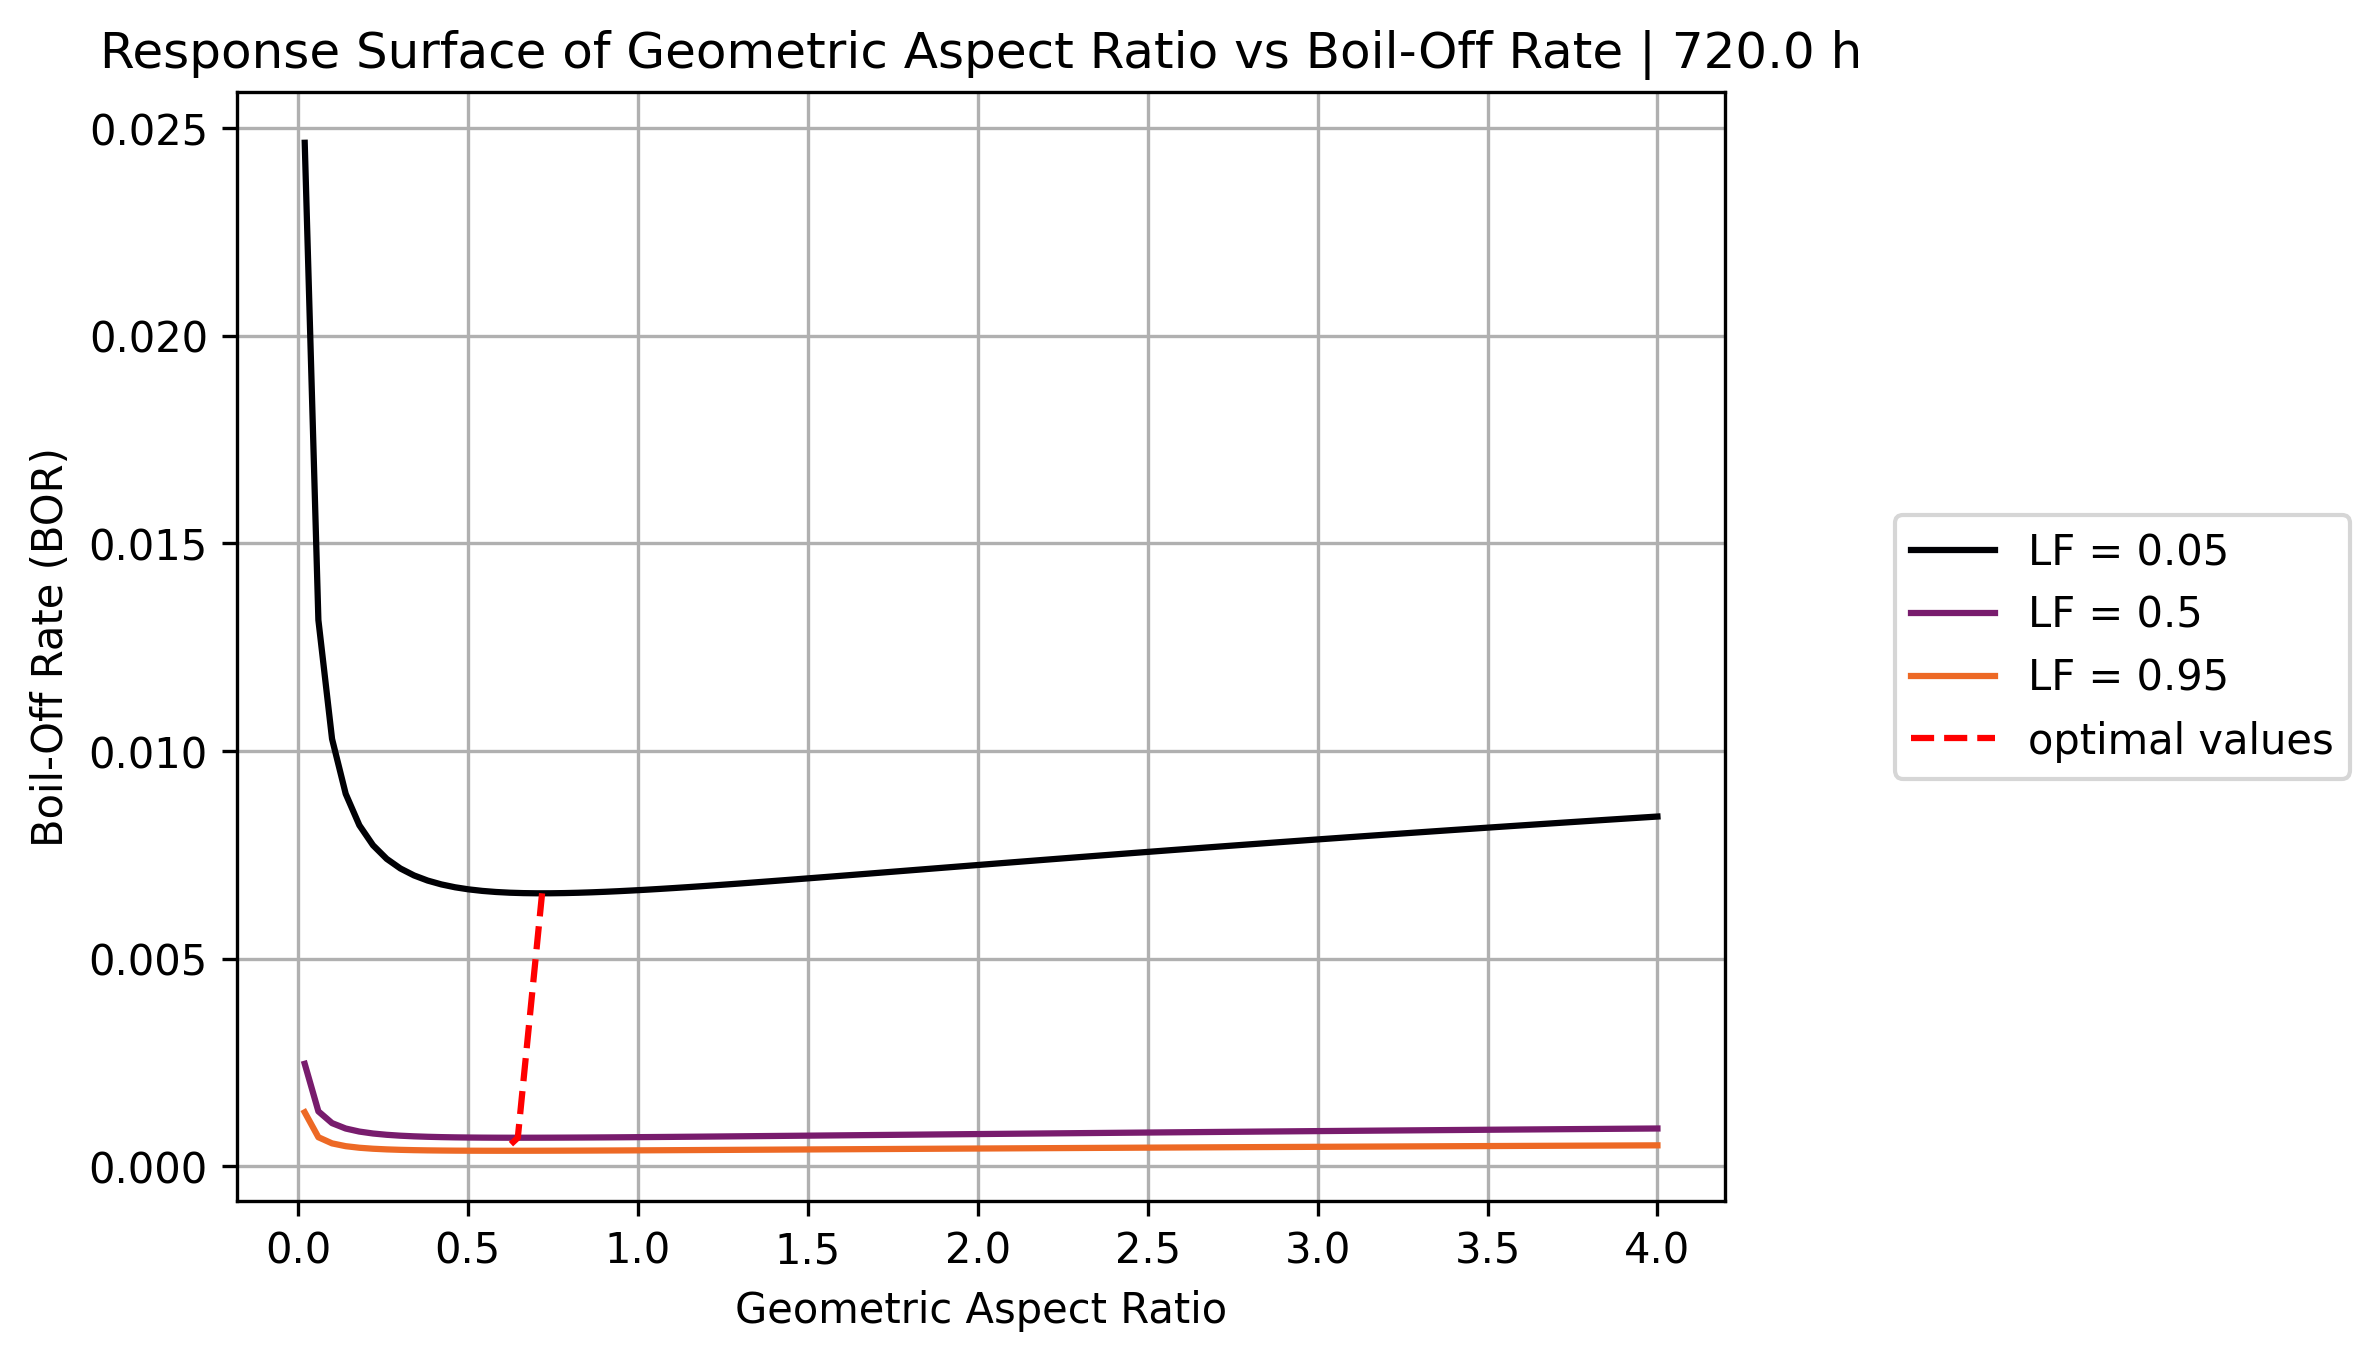

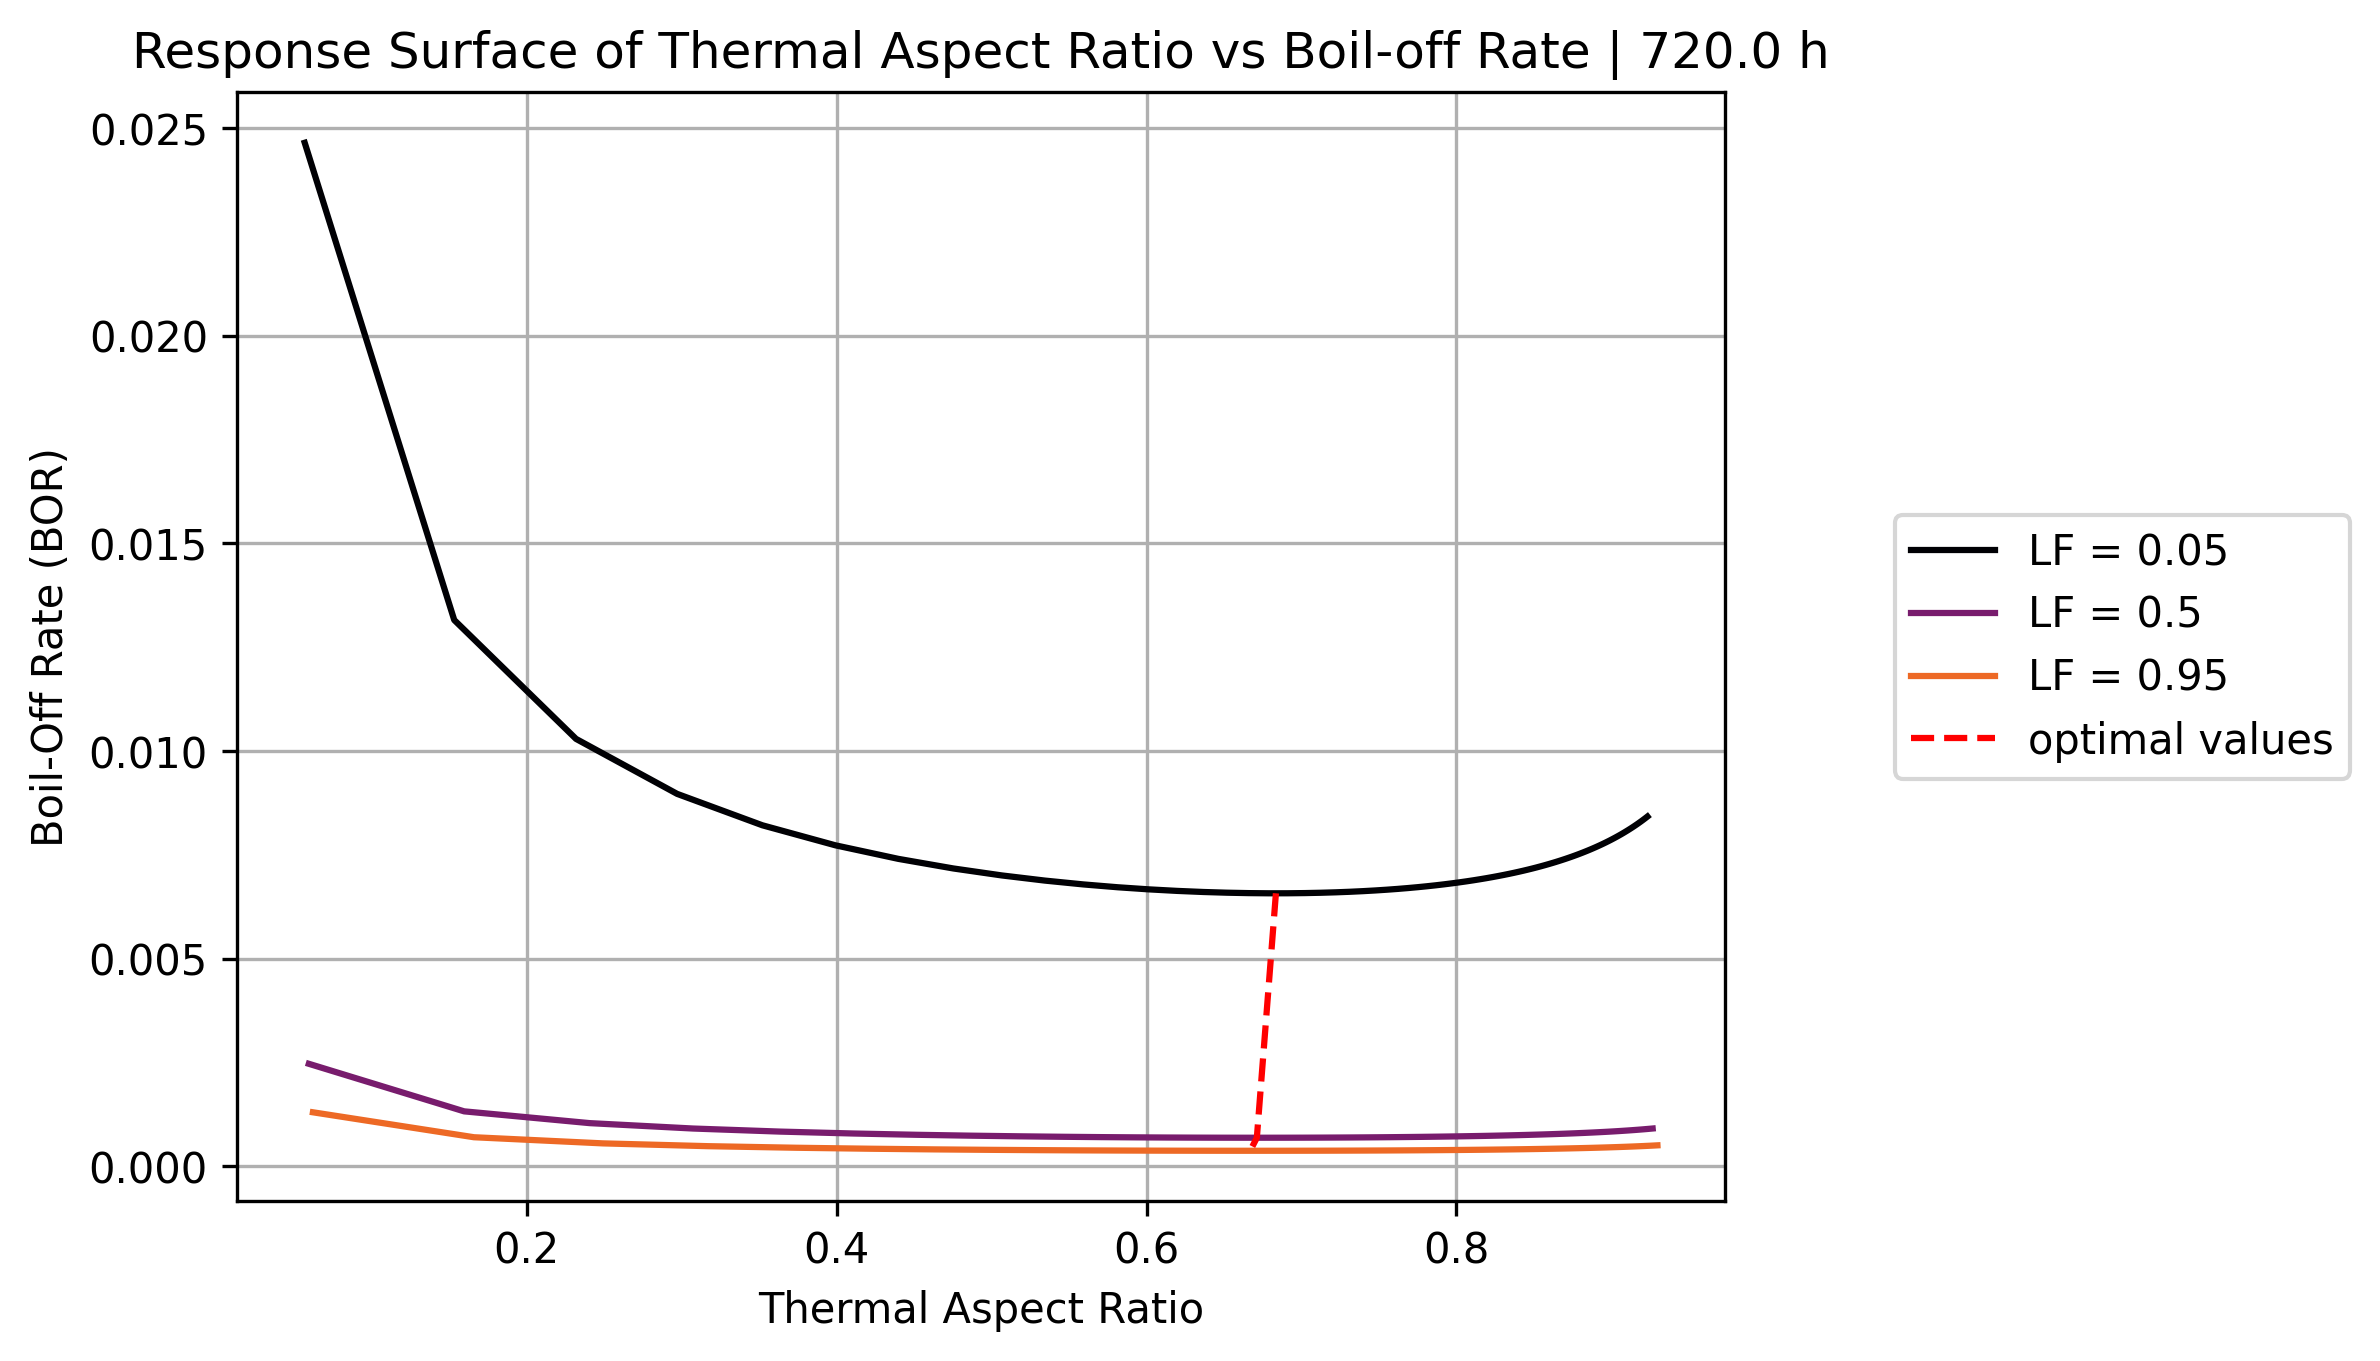

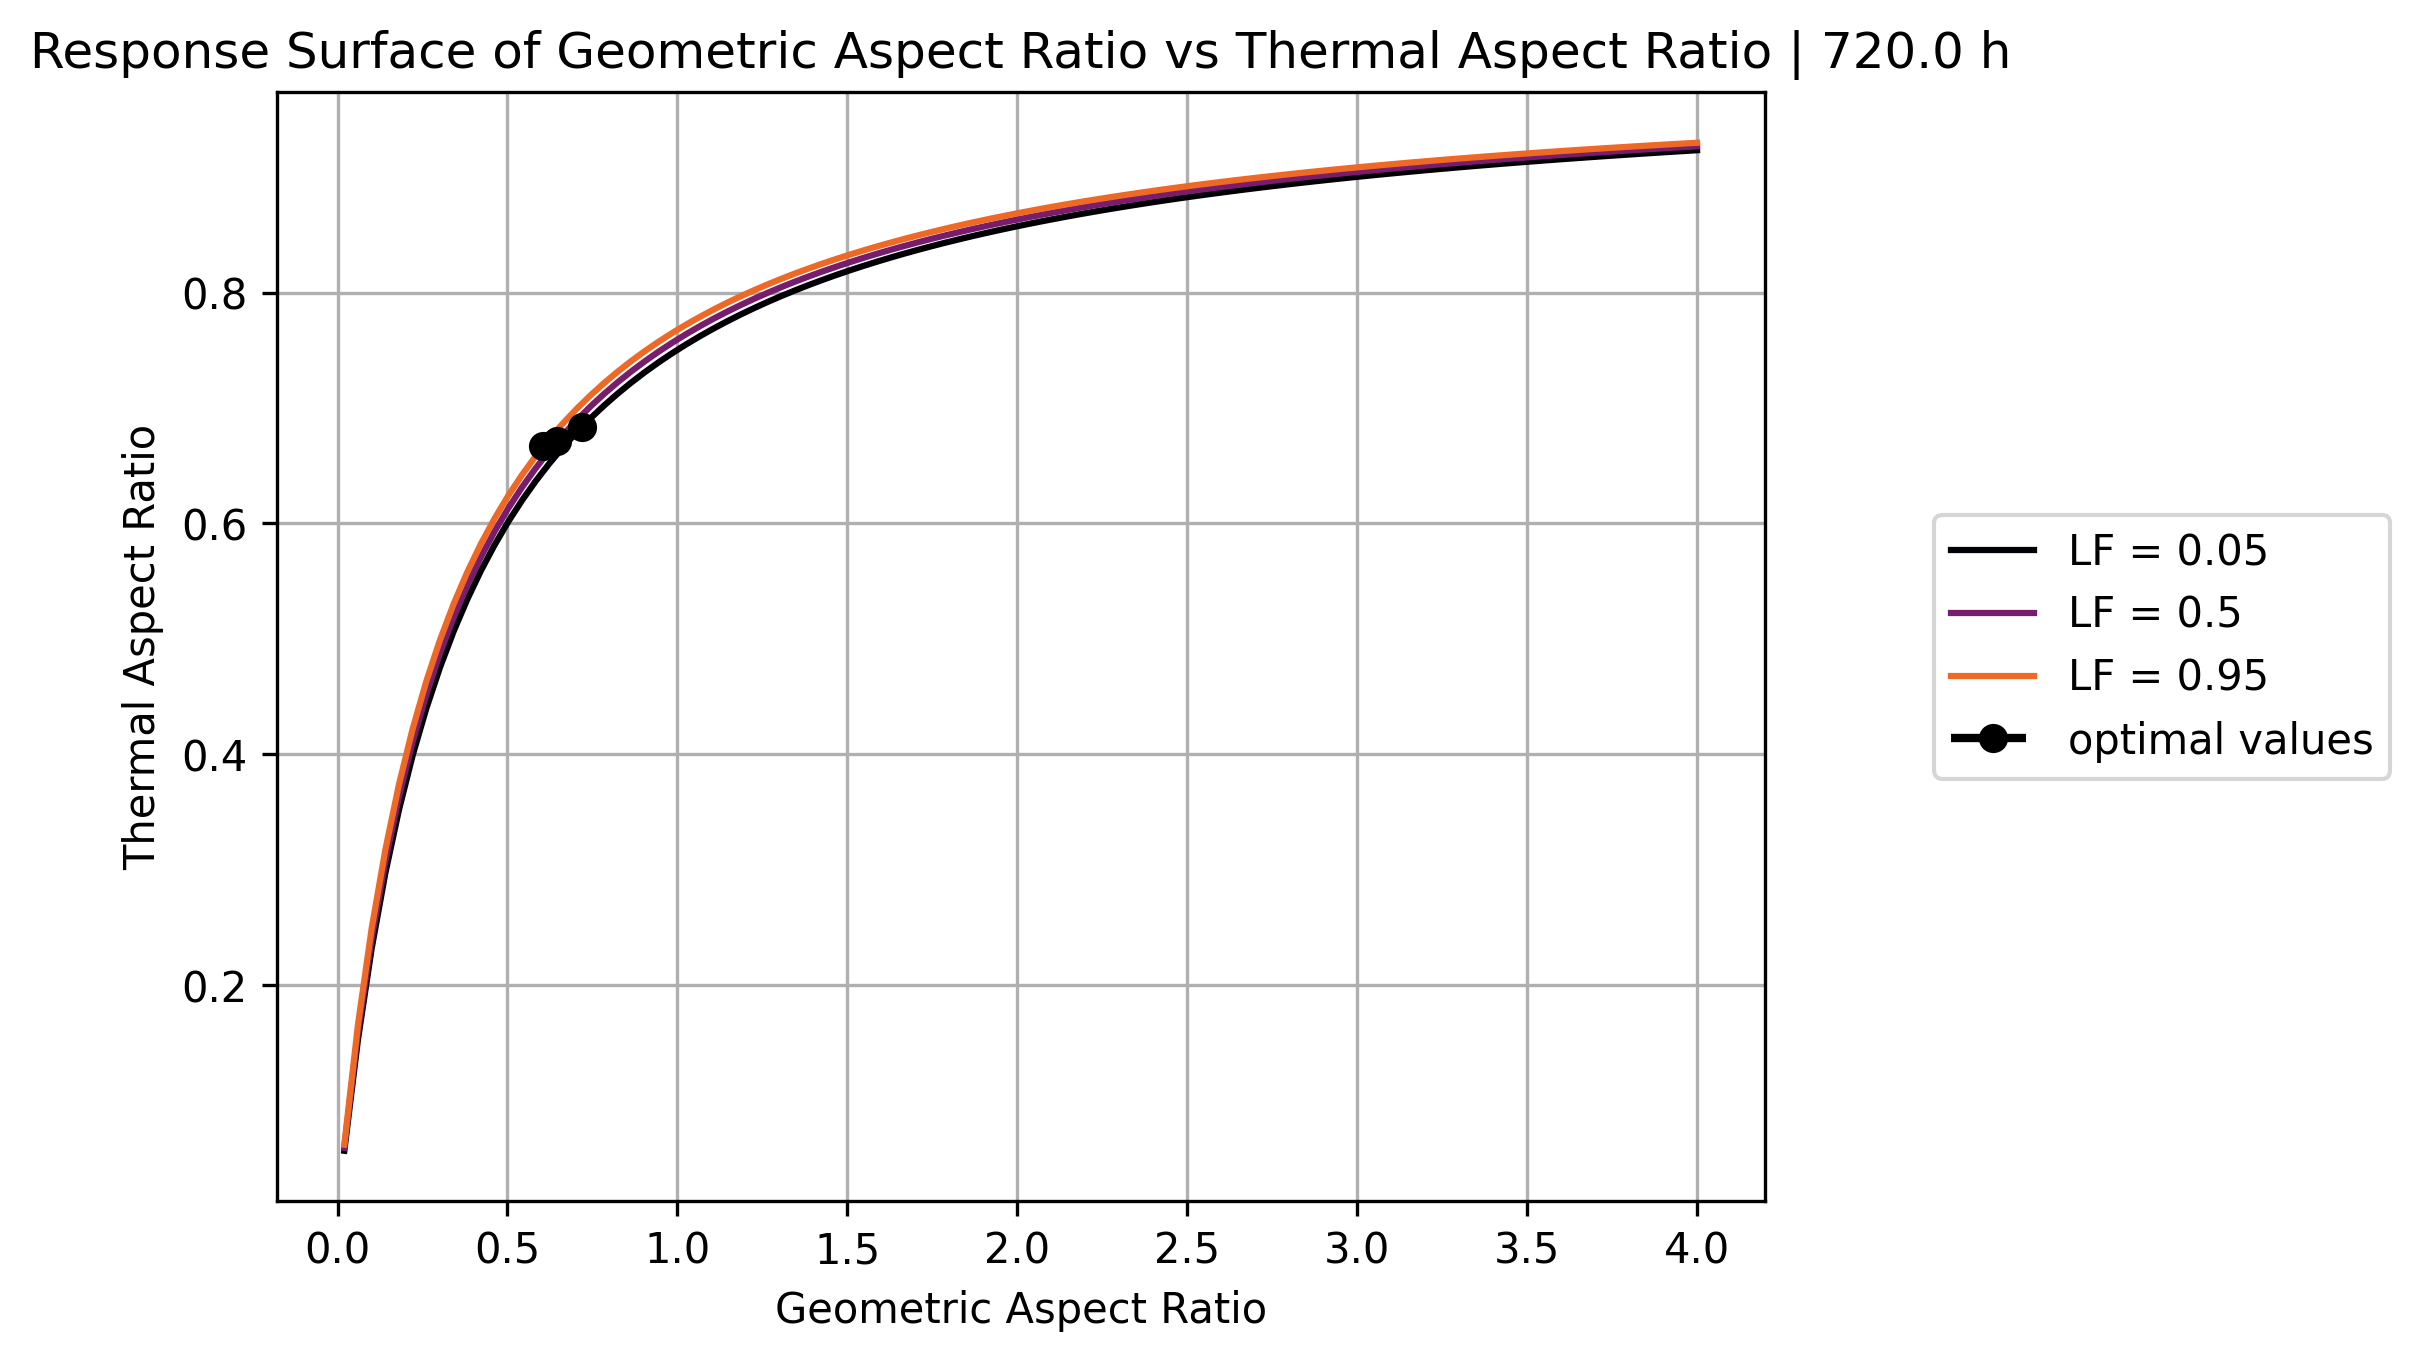

In [23]:
opti.plot_surface_response_thermal_aspect_ratio_liquid_filling(jnp.linspace(0.02, 4, 100), jnp.array([0.05,0.50,0.95]),720*3600)

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.